In [1]:
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import random
import math
import numpy as np
import torch
import torch.nn.functional as F

import sys
from pathlib import Path
import os

In [2]:
# Semilla para reproducibilidad de los experimentos
#random.seed(40)
#np.random.seed(40)
#torch.manual_seed(40)

In [3]:
# Si tenemos disponible GPU, lo usamos
# Chequeamos si tenemos disponible GPU (CUDA)
if torch.cuda.is_available():
    device = "cuda"
# Chequeamos si tenemos disponible aceleración por hardware en un chip de Apple (MPS)
elif torch.backends.mps.is_available():
    device = "mps"
# Por defecto usamos CPU
else:
    device = "cpu"

In [4]:
# Me aseguro de que el directorio raíz del proyecto esté en el sys.path
project_root = Path(os.path.abspath("")).parent

# Añado el directorio raíz al sys.path si no está ya presente
if project_root not in sys.path:
    sys.path.append(str(project_root))

In [5]:
# Importo las funciones de configuración
from src.config import raw_data_dir, models_dir, load_config

from src.utils.datasets import CustomDataset
from src.utils.metrics import calculate_metrics, calculate_compression_ratio

#from src.models.convolutional_autoencoder_model import ConvolutionalAutoencoder
from src.models.convolutional_autoencoder_model.model import ConvolutionalAutoencoder

Current working directory: /home/jorge/development/ImageReconstructionDL/notebooks
Loading configuration from /home/jorge/development/ImageReconstructionDL/src/config.yaml


In [6]:
def pad_to_multiple(x, multiple=64, mode='reflect'):
    """
    Agrega padding a las dimensiones de altura y anchura del tensor x
    para que sean múltiplos de 'multiple'.

    Args:
        x (torch.Tensor): Tensor de imagen de forma (N, C, H, W).
        multiple (int): Número al cual deben ser múltiplos H y W.
        mode (str): Modo de padding. Opciones comunes: 'constant', 'reflect', 'replicate'.

    Returns:
        torch.Tensor: Tensor con padding agregado.
        tuple: Cantidad de padding agregada en altura y anchura (pad_top, pad_bottom, pad_left, pad_right).
    """
    _, _, h, w = x.size()
    pad_h = (multiple - h % multiple) % multiple
    pad_w = (multiple - w % multiple) % multiple

    pad_top = pad_h // 2
    pad_bottom = pad_h - pad_top
    pad_left = pad_w // 2
    pad_right = pad_w - pad_left

    print(f"  Calculated padding - Top: {pad_top}, Bottom: {pad_bottom}, Left: {pad_left}, Right: {pad_right}")

    padding = (pad_left, pad_right, pad_top, pad_bottom)  # (left, right, top, bottom)
    x_padded = F.pad(x, padding, mode=mode, value=0)

    return x_padded, (pad_top, pad_bottom, pad_left, pad_right)

def crop_to_original(x, padding):
    """
    Recorta el padding de las dimensiones de altura y anchura del tensor x
    para restaurar las dimensiones originales.

    Args:
        x (torch.Tensor): Tensor de imagen con padding de forma (N, C, H_padded, W_padded).
        padding (tuple): Cantidad de padding agregada en altura y anchura (pad_top, pad_bottom, pad_left, pad_right).

    Returns:
        torch.Tensor: Tensor sin padding, con dimensiones originales.
    """
    pad_top, pad_bottom, pad_left, pad_right = padding
    _, _, H, W = x.size()

    if pad_bottom == 0:
        h_end = H
    else:
        h_end = -pad_bottom
    if pad_right == 0:
        w_end = W
    else:
        w_end = -pad_right

    return x[:, :, pad_top:h_end, pad_left:w_end]

In [7]:
# Cargo la configuración 
config = load_config()

Loading configuration from /home/jorge/development/ImageReconstructionDL/src/config.yaml


In [8]:
# Ruta de los datos
original_dir = raw_data_dir() / 'reduced_dataset' / 'data'

In [9]:
# Listar todas las imágenes en el directorio (sin usar glob)
image_files = []

In [10]:
# Recorre cada subdirectorio en original_dir
for sub_dir in os.listdir(original_dir):
    sub_dir_path = os.path.join(original_dir, sub_dir)
    if os.path.isdir(sub_dir_path):
        # Añade la ruta completa de cada imagen en el subdirectorio si es .png o .jpg
        image_files.extend(
            [os.path.join(sub_dir_path, f) for f in os.listdir(sub_dir_path) if f.endswith(('.png', '.jpg'))]
        )

In [11]:
# Seleccionar 6 imágenes al azar
selected_images = random.sample(image_files, 3)

In [12]:
# Transformo la imagen
transform = transforms.Compose([
    #transforms.Resize((2048, 2048)),
    transforms.ToTensor(),
])

In [13]:
# Cargar el modelo entrenado
encoder_filters = [64, 128, 256, 512, 1024, 2048]
decoder_filters = list(reversed(encoder_filters))
model_path = models_dir() / "trained" / "convolutional_autoencoder_model_final_best_hyperparameters_2_2.pth"
model = ConvolutionalAutoencoder(encoder_filters, decoder_filters).to(device)
model.load_state_dict(torch.load(model_path, map_location=device))

<All keys matched successfully>

Imagen 1:
  Dimensiones originales: H=720, W=1280
  Calculated padding - Top: 24, Bottom: 24, Left: 0, Right: 0
  Dimensiones después de padding: H_padded=768, W_padded=1280
  Padding aplicado: top=24, bottom=24, left=0, right=0
  Dimensiones después de reconstrucción (padded): H=768, W=1280
  Dimensiones después de recorte: H=720, W=1280
  Dimensiones coinciden después de recortar.
--------------------------------------------------
Imagen 2:
  Dimensiones originales: H=1080, W=1920
  Calculated padding - Top: 4, Bottom: 4, Left: 0, Right: 0
  Dimensiones después de padding: H_padded=1088, W_padded=1920
  Padding aplicado: top=4, bottom=4, left=0, right=0
  Dimensiones después de reconstrucción (padded): H=1088, W=1920
  Dimensiones después de recorte: H=1080, W=1920
  Dimensiones coinciden después de recortar.
--------------------------------------------------
Imagen 3:
  Dimensiones originales: H=2464, W=3264
  Calculated padding - Top: 16, Bottom: 16, Left: 0, Right: 0
  Dimensiones

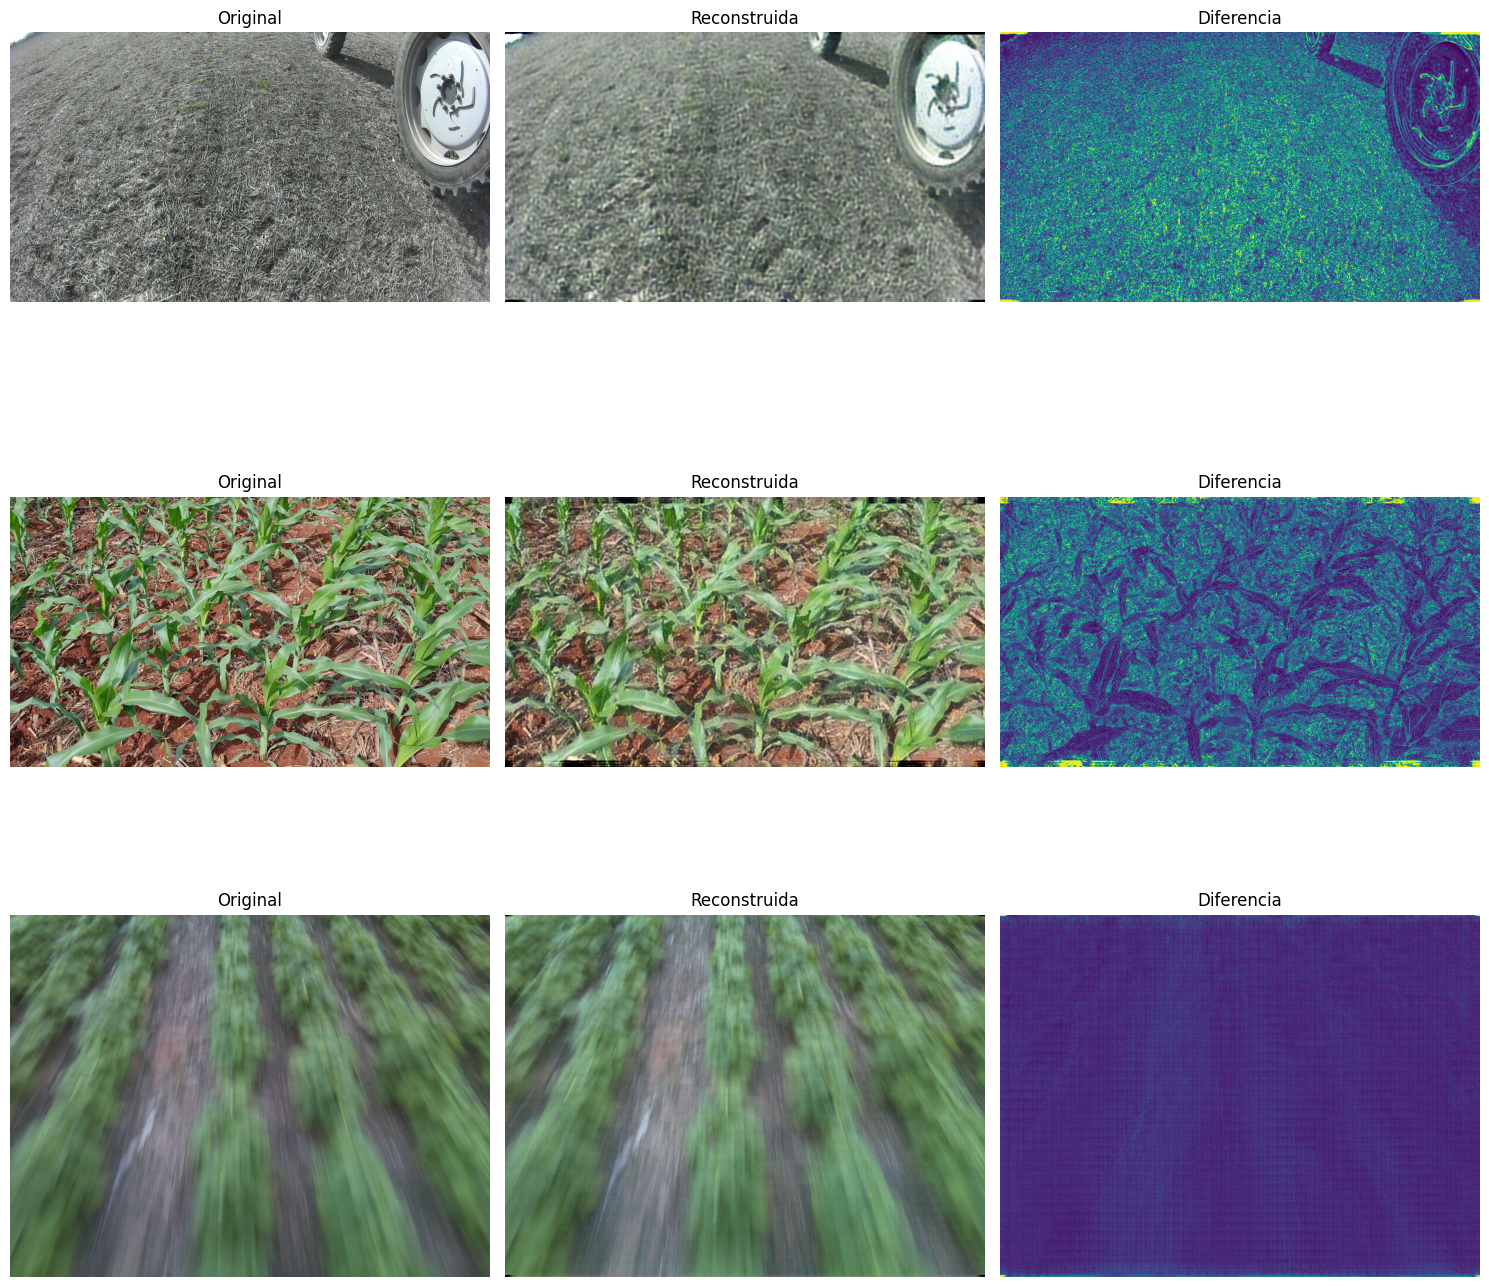

In [14]:
model.eval()
fig, axs = plt.subplots(len(selected_images), 3, figsize=(15, 15))

# Factor de amplificación para la diferencia
amplification_factor = 3.5  # Puedes ajustar este valor

for i, image_path in enumerate(selected_images):
    image = Image.open(image_path).convert("RGB")
    input_tensor = transform(image).unsqueeze(0).to(device)  # Forma: (1, C, H, W)

    # Guardar dimensiones originales
    _, _, orig_h, orig_w = input_tensor.size()

    print(f"Imagen {i+1}:")
    print(f"  Dimensiones originales: H={orig_h}, W={orig_w}")

    # Aplicar padding con múltiplo 64 y modo 'reflect'
    padded_tensor, padding = pad_to_multiple(input_tensor, multiple=64, mode='reflect')
    _, _, padded_h, padded_w = padded_tensor.size()

    print(f"  Dimensiones después de padding: H_padded={padded_h}, W_padded={padded_w}")
    print(f"  Padding aplicado: top={padding[0]}, bottom={padding[1]}, left={padding[2]}, right={padding[3]}")

    # Verificar que H_padded y W_padded sean múltiplos de 64
    assert padded_h % 64 == 0, f"H_padded={padded_h} no es múltiplo de 64"
    assert padded_w % 64 == 0, f"W_padded={padded_w} no es múltiplo de 64"

    with torch.no_grad():
        compressed = model.compress(padded_tensor)
        reconstructed_padded = model.decompress(compressed)

    _, _, recon_padded_h, recon_padded_w = reconstructed_padded.size()
    print(f"  Dimensiones después de reconstrucción (padded): H={recon_padded_h}, W={recon_padded_w}")

    # Recortar para restaurar dimensiones originales
    reconstructed = crop_to_original(reconstructed_padded, padding)
    _, _, recon_h, recon_w = reconstructed.size()

    print(f"  Dimensiones después de recorte: H={recon_h}, W={recon_w}")

    # Asegurarse de que las dimensiones coinciden
    if recon_h != orig_h or recon_w != orig_w:
        print(f"  ERROR: Dimensiones no coinciden después de recortar. Originales: ({orig_h}, {orig_w}), Reconstruidas: ({recon_h}, {recon_w})")
    else:
        print(f"  Dimensiones coinciden después de recortar.")

    # Convertir a numpy para mostrar las imágenes
    original_image_np = input_tensor.squeeze(0).cpu().numpy().transpose(1, 2, 0)
    reconstructed_image_np = reconstructed.squeeze(0).cpu().numpy().transpose(1, 2, 0)

    # Calcular la diferencia como el promedio de los valores absolutos entre las dos imágenes
    try:
        diff = np.mean(np.abs(original_image_np - reconstructed_image_np), axis=2)
    except ValueError as ve:
        print(f"  ERROR al calcular la diferencia: {ve}")
        diff = np.zeros((orig_h, orig_w))

    # Amplificar las diferencias para hacerlas más visibles
    diff_amplified = np.clip(diff * amplification_factor, 0, 1)

    # Mostrar las imágenes originales, reconstruidas y la diferencia amplificada
    axs[i, 0].imshow(original_image_np)
    axs[i, 0].set_title("Original")
    axs[i, 0].axis('off')

    axs[i, 1].imshow(reconstructed_image_np)
    axs[i, 1].set_title("Reconstruida")
    axs[i, 1].axis('off')

    # Mostrar la diferencia amplificada utilizando un colormap
    axs[i, 2].imshow(diff_amplified, cmap='viridis')  # Puedes cambiar 'viridis' por 'plasma' si prefieres
    axs[i, 2].set_title('Diferencia')
    axs[i, 2].axis('off')

    print("-" * 50)  # Separador para cada imagen

plt.tight_layout()
plt.show()